In [14]:
import oommfc as oc
import micromagneticdata as md
import discretisedfield as df
import functools
import matplotlib.pyplot as plt
import micromagneticmodel as mm
import os 
import re
import random

In [2]:
def get_mesh(D: float, w: float):
    r = D / 2
    p10 = (-r, -r, 0)
    p20 = (r, r, 16.8e-9)

    region = df.Region(p1=p10, p2=p20)
    subregions = {
        "bottom": df.Region(p1=p10, p2=(r, r, 8e-9)),
        "spacer": df.Region(p1=(-r, -r, 8e-9), p2=(r, r, (8 + w) * 1e-9)),
        "top": df.Region(p1=(-r, -r, (8 + w) * 1e-9), p2=p20),
    }

    mesh = df.Mesh(region=region, cell=(3e-9, 3e-9, 8e-10), subregions=subregions)

    return mesh


def Ms_init(pos, Ms, D):
    x, y, z = pos
    r = D / 2
    if (x**2 + y**2) ** 0.5 < r:
        if z < 8e-9:
            return -Ms
        else:
            return Ms
    else:
        return 0


def m_init(pos, d):
    x, y, z = pos
    r = d / 2
    if (x**2 + y**2) ** 0.5 < r:
        return (0, 0, -1)
    else:
        return (0, 0, 1)

In [4]:
D = 300e-9
w = 0.8
Ms = 280e3
mesh = get_mesh(D, w)

In [20]:
RESULTS_PATH_HYSTERESIS = "../results/saf_skyrmion-0.8nm-d_1-hysteresis-llg-old"
d = 40e-9
Ms_fun = functools.partial(Ms_init, Ms=Ms, D=D)
m_fun = functools.partial(m_init, d=d)

## ENERGY TERMS
A = 1e-11  # J/m
sigma = -0.3e-3  # J/m^2
K = 0.1e6  # J/m^3
dmi = 1e-3  # J/m^2
temp = 100 # K
system = mm.System(name="saf_skyrmion_hysteresis_llg", T=100)
system.energy = (
    mm.Exchange(A=A)
    + mm.RKKY(sigma=sigma, sigma2=0, subregions=["bottom", "top"])
    + mm.UniaxialAnisotropy(K=K, u=(0, 0, 1))
    + mm.Demag()
    + mm.DMI(D=dmi, crystalclass="Cnv_z")
)

## DYNAMICS
alpha = 0.3
gamma0 = 2.211e5 # m/As
system.dynamics = mm.Precession(gamma0=gamma0) + mm.Damping(alpha=alpha)

## MAGNETIZATION
norm = {"bottom": Ms_fun, "top": Ms_fun, "spacer": 0}
system.m = df.Field(mesh, nvdim=3, value=m_fun, norm=norm, valid="norm")

## EVOLVER
evolver = oc.Xf_ThermHeunEvolver(
    min_timestep=1e-14,
    max_timestep=1e-14,
    uniform_seed=10
)

evolver_2 = oc.UHH_ThetaEvolver(fixed_timestep=2e-13)
## DRIVING
sim_time = 2 # ns
dm_dt = 1 # degrees/ns
md = oc.TimeDriver(evolver=evolver)
md.drive(
    system,
    t=sim_time*1e-9,
    n=200,
    n_threads=8,
    dirname=f"{RESULTS_PATH_HYSTERESIS}/saf_skyrmion-{D / 1e-9:.0f}nm-{Ms / 1e3:.0f}kA_m-200steps-{sim_time}ns-{temp}K"
)

Running OOMMF (ExeOOMMFRunner)[2025-08-05T14:50:10]... (8710.2 s)


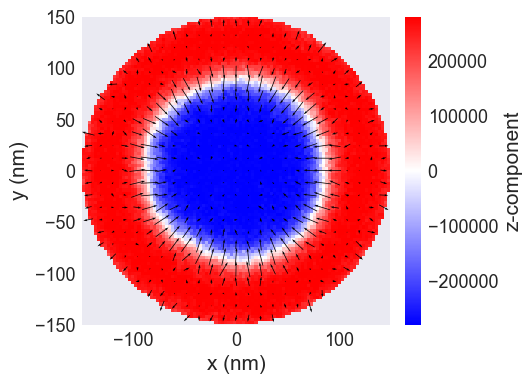

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
system.m.sel(z=12e-9).z.mpl.scalar(ax=ax, cmap="bwr", colorbar_label="z-component")
system.m.sel(z=12e-9).resample((25, 25)).mpl.vector(
    ax=ax, use_color=False, color="black"
)

In [23]:
Hmin = (0, 0, -4 / mm.consts.mu0)
Hmax = (0, 0, 4 / mm.consts.mu0)

hd = oc.HysteresisDriver()
hd.drive(
    system,
    dirname=f"{RESULTS_PATH_HYSTERESIS}/saf_skyrmion-{D / 1e-9:.0f}nm-{Ms / 1e3:.0f}kA_m-200steps-{sim_time}ns-{temp}K-hysteresis",
    Hsteps=[[(0, 0, 0), Hmax, 10], [Hmax, Hmin, 10], [Hmin, Hmax, 20]]
)

Running OOMMF (ExeOOMMFRunner)[2025-08-05T17:45:40]... (399.3 s)


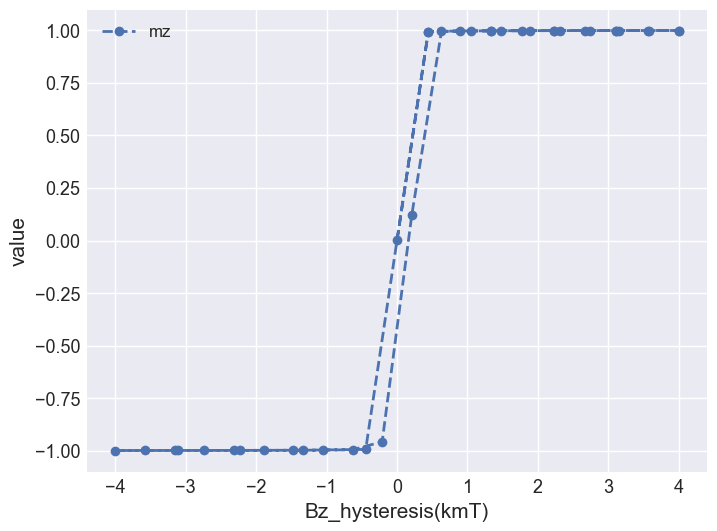

In [24]:
system.table.mpl(
    x="Bz_hysteresis", y=["mz"], marker="o", linewidth=2, linestyle="dashed"
)